In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Admission_Predict.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (400, 9)

First 5 rows:
   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  

Data Types:
Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

Missing Values:
S

In [2]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


In [3]:
df["admission"] = (df["Chance of Admit"] >= 0.5).astype(int)

print(df[["Chance of Admit", "admission"]].head(10))

   Chance of Admit  admission
0             0.92          1
1             0.76          1
2             0.72          1
3             0.80          1
4             0.65          1
5             0.90          1
6             0.75          1
7             0.68          1
8             0.50          1
9             0.45          0


In [4]:
print("Admission Class Distribution:")
print(df["admission"].value_counts())

print("\nAdmission Class Percentage:")
print(df["admission"].value_counts(normalize=True) * 100)

Admission Class Distribution:
admission
1    367
0     33
Name: count, dtype: int64

Admission Class Percentage:
admission
1    91.75
0     8.25
Name: proportion, dtype: float64


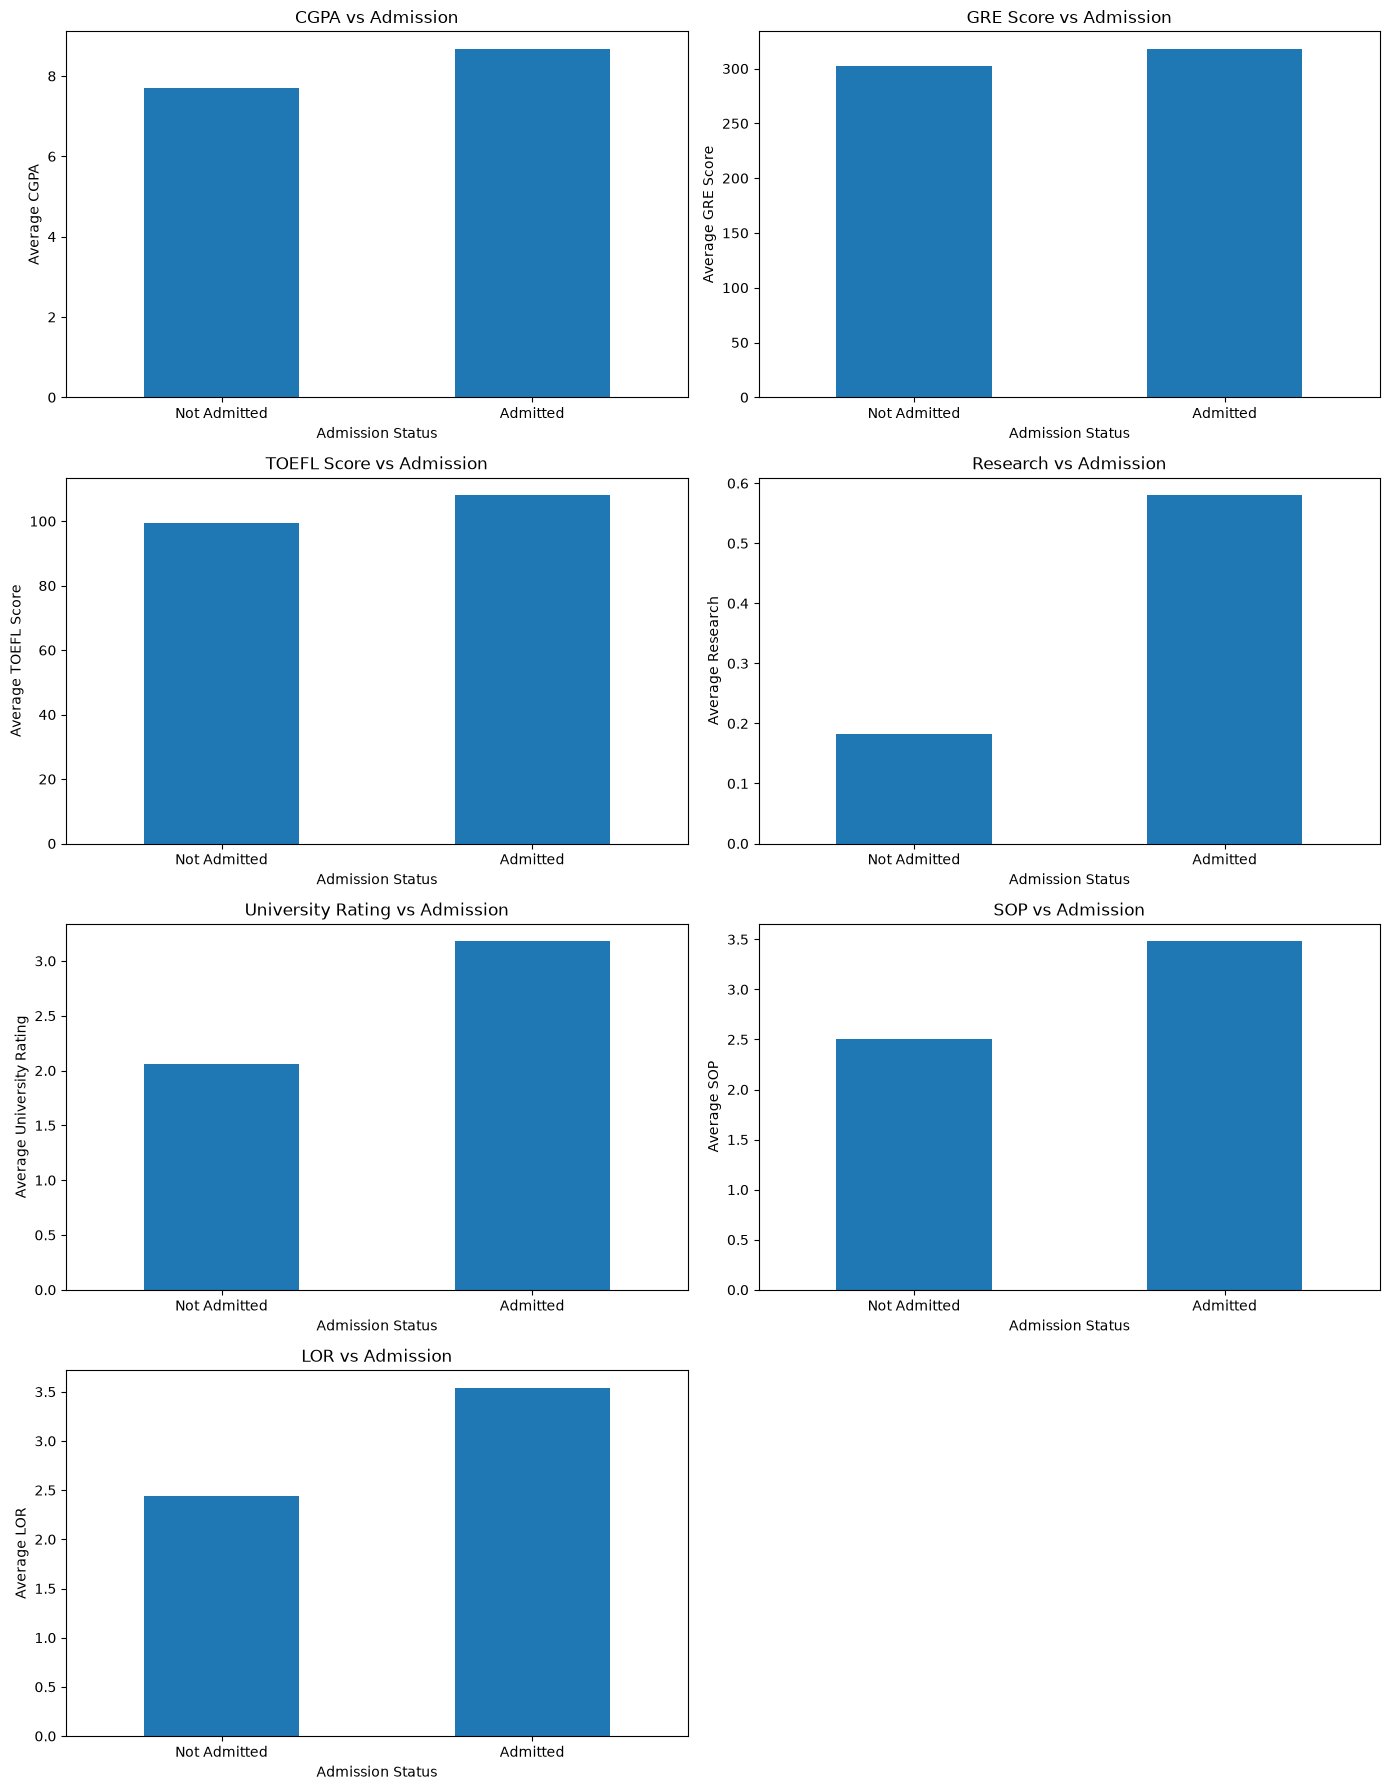

In [5]:
import matplotlib.pyplot as plt

features = [
    "CGPA",
    "GRE Score",
    "TOEFL Score",
    "Research",
    "University Rating",
    "SOP",
    "LOR"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for ax, feature in zip(axes.flat, features):

    df.groupby("admission")[feature].mean().plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"{feature} vs Admission")
    ax.set_xlabel("Admission Status")
    ax.set_ylabel(f"Average {feature}")
    ax.set_xticklabels(
        ["Not Admitted", "Admitted"],
        rotation=0
    )

# Hide the unused 8th subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

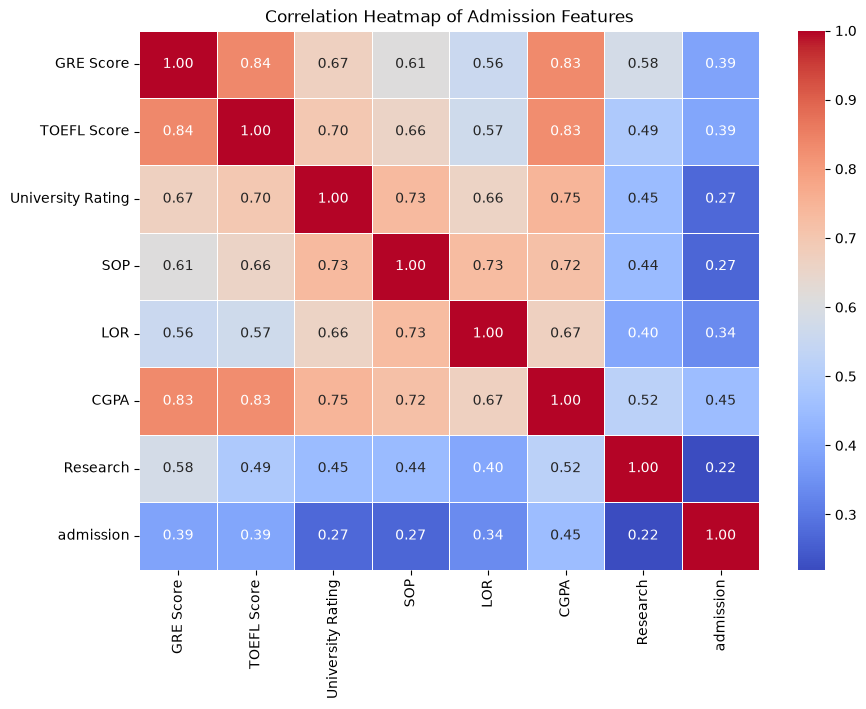

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
correlation_data = df[
    [
        "GRE Score",
        "TOEFL Score",
        "University Rating",
        "SOP",
        "LOR",
        "CGPA",
        "Research",
        "admission"
    ]
]

# Calculate correlation
correlation_matrix = correlation_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Admission Features")
plt.show()

In [7]:
df["average_test_score"] = (
    df["GRE Score"] + df["TOEFL Score"]
) / 2

print(df[
    ["GRE Score", "TOEFL Score", "average_test_score"]
].head())

   GRE Score  TOEFL Score  average_test_score
0        337          118               227.5
1        324          107               215.5
2        316          104               210.0
3        322          110               216.0
4        314          103               208.5


In [8]:
X = df.drop(
    ["Serial No.", "Chance of Admit", "admission"],
    axis=1
)

y = df["admission"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (400, 8)
y shape: (400,)

Features:
['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'average_test_score']


In [9]:
from sklearn.model_selection import train_test_split

# 60% Training, 40% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# Split remaining 40% into 20% Validation and 20% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (240, 8) (240,)
Validation set: (80, 8) (80,)
Test set: (80, 8) (80,)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training scaled shape:", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)
print("Test scaled shape:", X_test_scaled.shape)

Training scaled shape: (240, 8)
Validation scaled shape: (80, 8)
Test scaled shape: (80, 8)


In [11]:


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [12]:
weights = np.zeros(X_train_scaled.shape[1])
bias = 0

print("Initial weights:", weights)
print("Initial bias:", bias)

Initial weights: [0. 0. 0. 0. 0. 0. 0. 0.]
Initial bias: 0


In [13]:
# Calculate linear output
z = np.dot(X_train_scaled, weights) + bias

# Convert to probability
predictions = sigmoid(z)

# Prevent log(0)
predictions = np.clip(
    predictions,
    1e-15,
    1 - 1e-15
)

# Calculate Log Loss
loss = -np.mean(
    y_train * np.log(predictions) +
    (1 - y_train) * np.log(1 - predictions)
)

print("Log Loss:", loss)

Log Loss: 0.6931471805599453


In [14]:
learning_rate = 0.01
iterations = 1000

weights = np.zeros(X_train_scaled.shape[1])
bias = 0

losses = []

for i in range(iterations):

    # 1. Prediction
    z = np.dot(X_train_scaled, weights) + bias
    predictions = sigmoid(z)

    # 2. Prevent log(0)
    predictions = np.clip(
        predictions,
        1e-15,
        1 - 1e-15
    )

    # 3. Calculate Log Loss
    loss = -np.mean(
        y_train * np.log(predictions) +
        (1 - y_train) * np.log(1 - predictions)
    )

    losses.append(loss)

    # 4. Calculate gradients
    dw = (1 / len(y_train)) * np.dot(
        X_train_scaled.T,
        predictions - y_train
    )

    db = (1 / len(y_train)) * np.sum(
        predictions - y_train
    )

    # 5. Update weights and bias
    weights -= learning_rate * dw
    bias -= learning_rate * db

print("Final Loss:", losses[-1])
print("Final Bias:", bias)
print("Final Weights:", weights)

Final Loss: 0.23984482853333067
Final Bias: 1.8326496613464571
Final Weights: [ 0.12169561  0.17602731 -0.01986202  0.03493871  0.18467701  0.32538953
 -0.0197381   0.14595615]


In [15]:
learning_rates = [0.001, 0.01, 0.1, 1.0]

final_losses = {}

for lr in learning_rates:

    weights_lr = np.zeros(X_train_scaled.shape[1])
    bias_lr = 0

    for i in range(1000):

        # Prediction
        z = np.dot(
            X_train_scaled,
            weights_lr
        ) + bias_lr

        predictions = sigmoid(z)

        # Prevent log(0)
        predictions = np.clip(
            predictions,
            1e-15,
            1 - 1e-15
        )

        # Log Loss
        loss = -np.mean(
            y_train * np.log(predictions) +
            (1 - y_train) * np.log(1 - predictions)
        )

        # Gradient
        dw = (1 / len(y_train)) * np.dot(
            X_train_scaled.T,
            predictions - y_train
        )

        db = (1 / len(y_train)) * np.sum(
            predictions - y_train
        )

        # Update
        weights_lr -= lr * dw
        bias_lr -= lr * db

    final_losses[lr] = loss

print("Learning Rate Comparison\n")

for lr in learning_rates:
    print(
        "Learning Rate:",
        lr,
        "| Final Loss:",
        final_losses[lr]
    )

Learning Rate Comparison

Learning Rate: 0.001 | Final Loss: 0.5296058478919538
Learning Rate: 0.01 | Final Loss: 0.23984482853333067
Learning Rate: 0.1 | Final Loss: 0.14957074517052557
Learning Rate: 1.0 | Final Loss: 0.1387714675686687


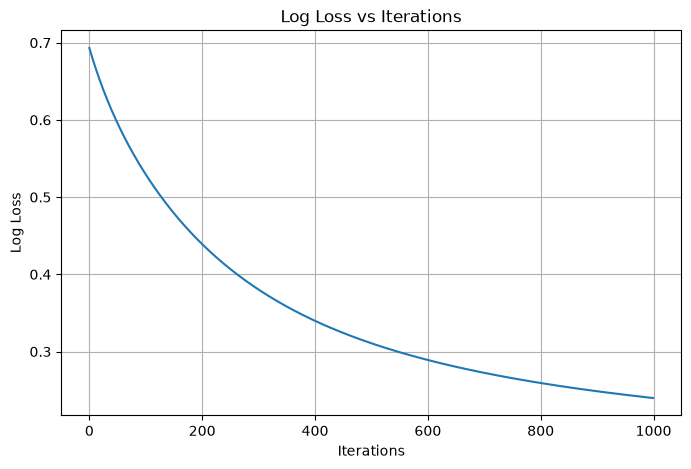

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(losses)

plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Log Loss vs Iterations")

plt.grid(True)
plt.show()

In [17]:
# Calculate test scores
z_test = np.dot(X_test_scaled, weights) + bias

# Convert scores into probabilities
y_prob = sigmoid(z_test)

# Convert probabilities into classes
y_pred = (y_prob >= 0.5).astype(int)

print("First 10 probabilities:")
print(y_prob[:10])

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

print("\nActual classes:")
print(y_test.values[:10])

First 10 probabilities:
[0.64451829 0.91481449 0.91425377 0.93455253 0.91698887 0.82023994
 0.94415915 0.61904689 0.88636031 0.79970957]

First 10 predicted classes:
[1 1 1 1 1 1 1 1 1 1]

Actual classes:
[1 1 1 1 1 1 1 1 1 1]


In [18]:
accuracy = np.mean(y_pred == y_test.values)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Accuracy: 0.9375
Accuracy Percentage: 93.75


In [19]:
TP = np.sum((y_test.values == 1) & (y_pred == 1))
TN = np.sum((y_test.values == 0) & (y_pred == 0))
FP = np.sum((y_test.values == 0) & (y_pred == 1))
FN = np.sum((y_test.values == 1) & (y_pred == 0))

print("True Positive (TP):", TP)
print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)

True Positive (TP): 73
True Negative (TN): 2
False Positive (FP): 5
False Negative (FN): 0


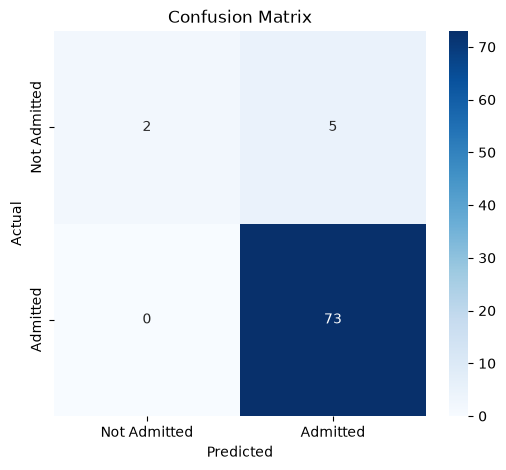

In [20]:
confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Admitted", "Admitted"],
    yticklabels=["Not Admitted", "Admitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [21]:
precision = TP / (TP + FP) if (TP + FP) != 0 else 0

recall = TP / (TP + FN) if (TP + FN) != 0 else 0

f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) != 0
    else 0
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Precision: 0.9358974358974359
Recall: 1.0
F1 Score: 0.9668874172185431


In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Admitted", "Admitted"]
    )
)

              precision    recall  f1-score   support

Not Admitted       1.00      0.29      0.44         7
    Admitted       0.94      1.00      0.97        73

    accuracy                           0.94        80
   macro avg       0.97      0.64      0.71        80
weighted avg       0.94      0.94      0.92        80



In [23]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("AUC:", auc_score)

AUC: 0.9628180039138943


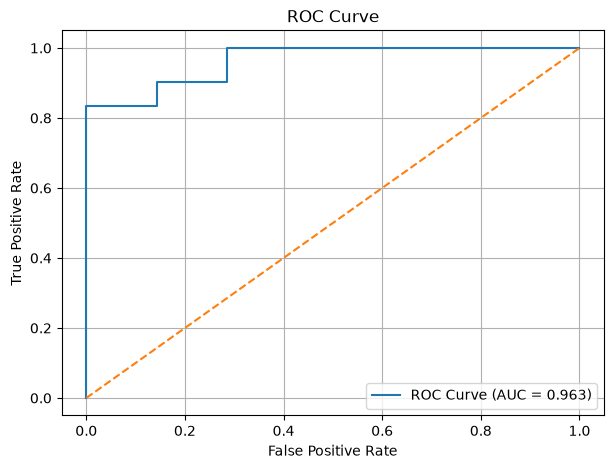

In [24]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

In [25]:
feature_names = X.columns

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": weights
})

coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficient_df)

              Feature  Coefficient
5                CGPA     0.325390
4                 LOR     0.184677
1         TOEFL Score     0.176027
7  average_test_score     0.145956
0           GRE Score     0.121696
3                 SOP     0.034939
6            Research    -0.019738
2   University Rating    -0.019862


In [26]:
coefficient_df["Absolute Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

top_10 = coefficient_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
).head(10)

print("Top 10 Features:")
print(top_10)

Top 10 Features:
              Feature  Coefficient  Absolute Coefficient
5                CGPA     0.325390              0.325390
4                 LOR     0.184677              0.184677
1         TOEFL Score     0.176027              0.176027
7  average_test_score     0.145956              0.145956
0           GRE Score     0.121696              0.121696
3                 SOP     0.034939              0.034939
2   University Rating    -0.019862              0.019862
6            Research    -0.019738              0.019738


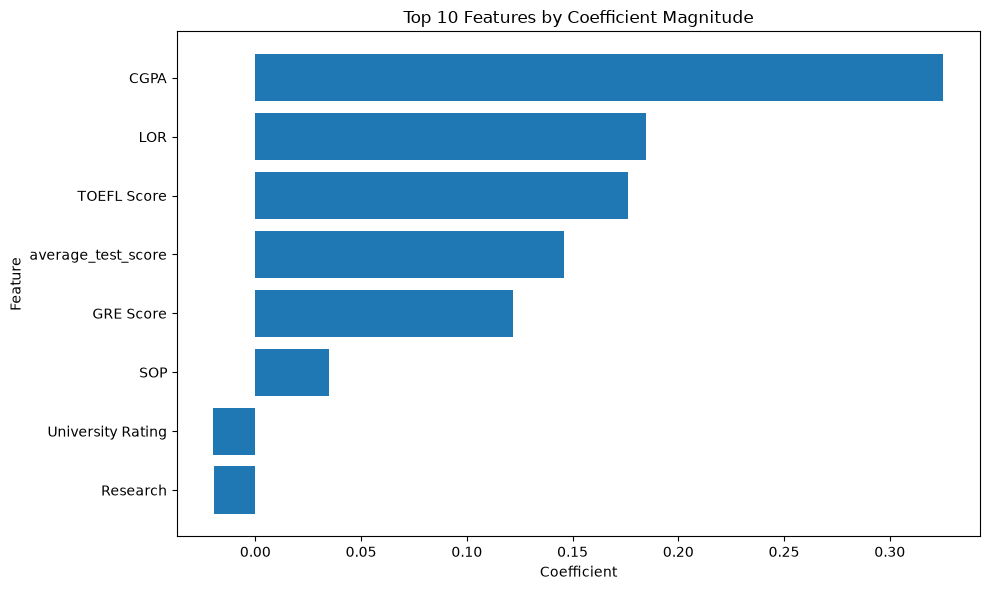

In [27]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Feature"],
    top_10["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features by Coefficient Magnitude")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [28]:
print("========== MODEL SUMMARY ==========")

print("Training Samples:", len(X_train))
print("Validation Samples:", len(X_val))
print("Test Samples:", len(X_test))

print("\nTest Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)
print("AUC:", auc_score)

print("\nNumber of Features:", X.shape[1])

========== MODEL SUMMARY ==========
Training Samples: 240
Validation Samples: 80
Test Samples: 80

Test Accuracy: 0.9375
Precision: 0.9358974358974359
Recall: 1.0
F1 Score: 0.9668874172185431
AUC: 0.9628180039138943

Number of Features: 8


In [30]:
import pickle

model_data = {
    "weights": weights,
    "bias": bias,
    "scaler": scaler,
    "features": X.columns.tolist()
}

with open("university_admission_model.pkl", "wb") as file:
    pickle.dump(model_data, file)

print("Model saved successfully!")
print("File: university_admission_model.pkl")

Model saved successfully!
File: university_admission_model.pkl
